# Paired multi-model analysis of scRNA-seq and scProtein-seq data

## 2_GSE128639 dataset

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.6'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_adt_data(adt_file):
    """Read ADT data from the specified CSV file and return it as an AnnData object."""
    adt_df = pd.read_csv(adt_file, index_col=0)
    adt_df = adt_df.T  # Transpose to match AnnData format
    adt = sc.AnnData(X=adt_df.values)
    adt.var_names = adt_df.columns  # Set feature names
    adt.obs_names = adt_df.index  # Set barcode names
    return adt

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, adt_file, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        adt_file (str): Path to the CSV file containing ADT data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(adt_file)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        adt = read_adt_data(adt_file)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    adt.obs = adt.obs.join(metadata, how="left")

    return {"rna": rna, "adt": adt}

# Example usage with provided file paths
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/2_GSE128639/RNA'
adt_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/2_GSE128639/ADT.csv'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/2_GSE128639/metadata.csv'

# Read the data
data = read_multiomics_data(rna_dir, adt_file, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
adt = data["adt"]
rna.layers['counts'] = rna.X.copy()
adt.layers['counts'] = adt.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:38<00:00, 12.91s/it]


In [4]:
## downsample 
import numpy as np

# 设定下采样的细胞数量
n_cells = 10000

# 设置随机种子以确保重复性
random_seed = 42
np.random.seed(random_seed)

# 随机选择 1 万个细胞的索引
random_indices = np.random.choice(rna.shape[0], n_cells, replace=False)

# 根据随机索引选择细胞
adata_rna_sampled = rna[random_indices].copy()
adata_adt_sampled = adt[random_indices].copy()

         Falling back to preprocessing with `sc.pp.pca` and default params.


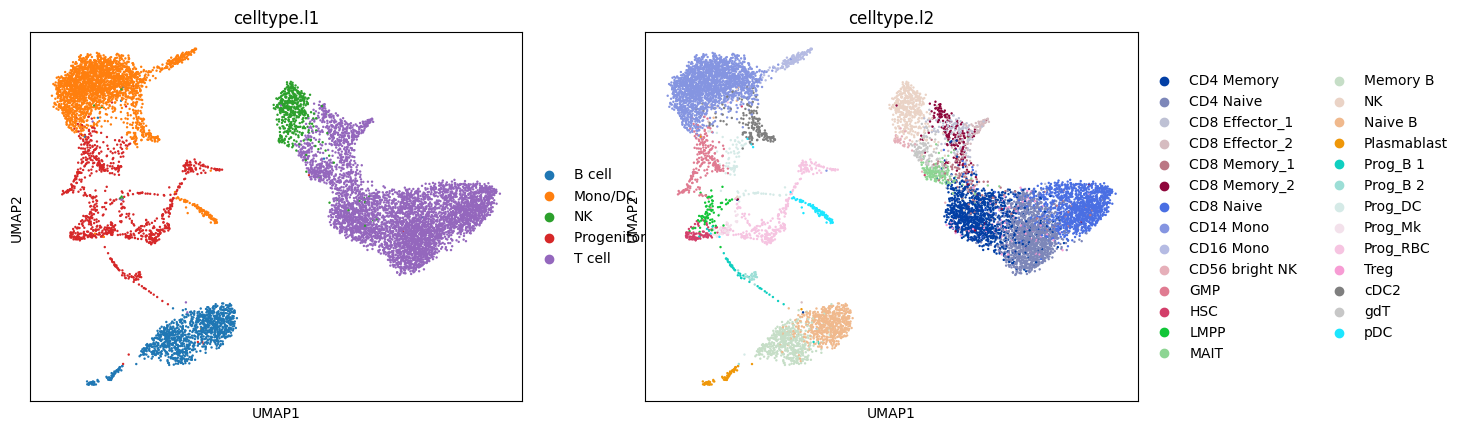

In [11]:
# process all RNA features
rna_adata = adata_rna_sampled.copy()
sc.pp.normalize_total(rna_adata)
sc.pp.log1p(rna_adata)
sc.pp.highly_variable_genes(rna_adata)
# only retain highly variable genes
rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
sc.pp.scale(rna_adata)

# plot UMAPs of rna cells based on all active rna markers
sc.pp.neighbors(rna_adata, n_neighbors=15)
sc.tl.umap(rna_adata)
sc.pl.umap(rna_adata, color=['celltype.l1','celltype.l2'])

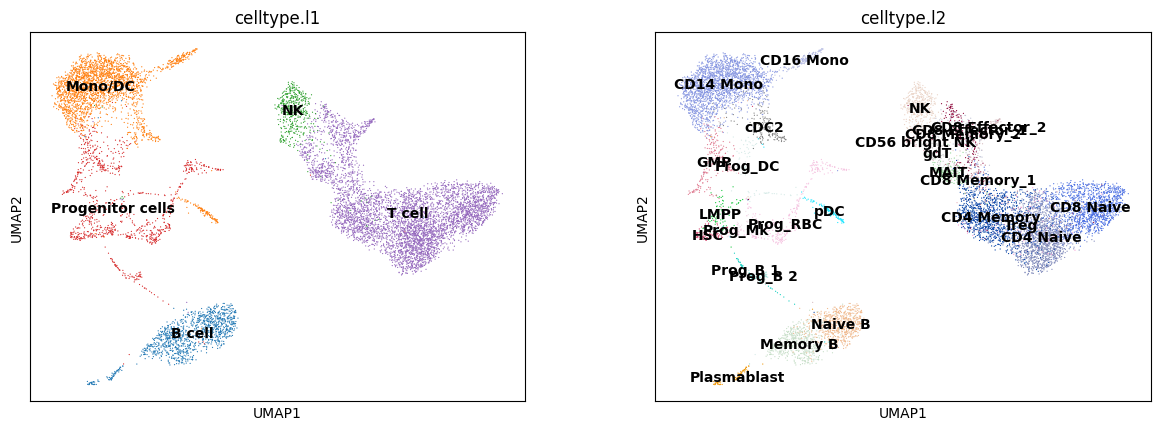

In [12]:
sc.pl.umap(rna_adata, color=['celltype.l1','celltype.l2'], wspace=0.15, show=True, size=3, legend_loc='on data')

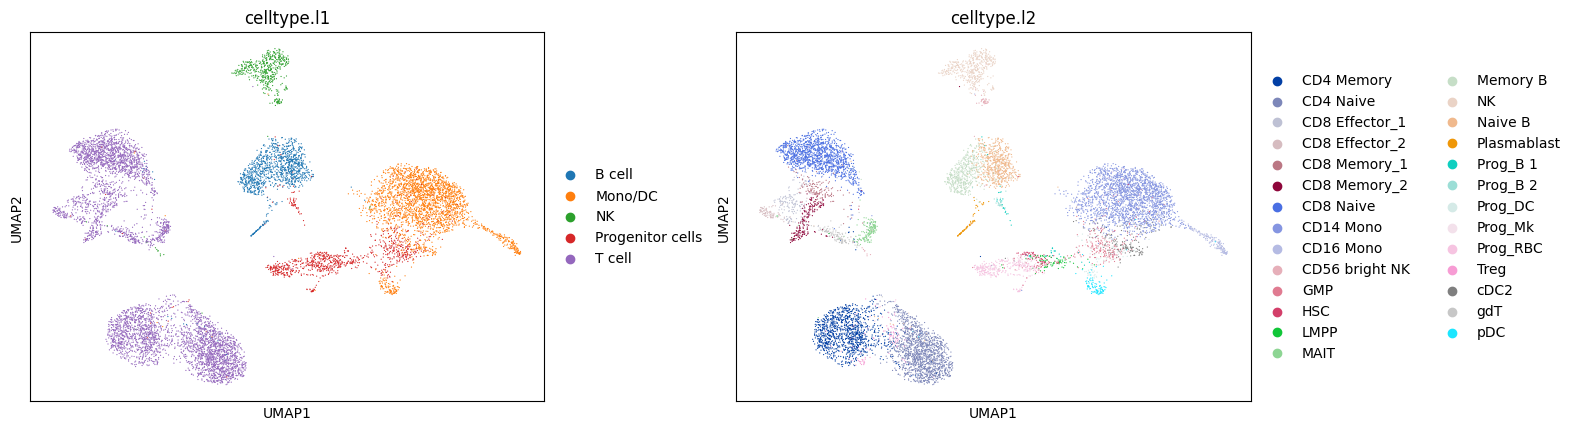

In [9]:
# process all protein features
protein_adata = adata_adt_sampled.copy()

sc.pp.normalize_total(protein_adata)
sc.pp.log1p(protein_adata)
sc.pp.scale(protein_adata)

# plot UMAPs of protein cells based on all active protein markers
sc.pp.neighbors(protein_adata, n_neighbors=15)
sc.tl.umap(protein_adata)
sc.pl.umap(protein_adata, color=['celltype.l1','celltype.l2'], wspace=0.25, show=True, size=3)

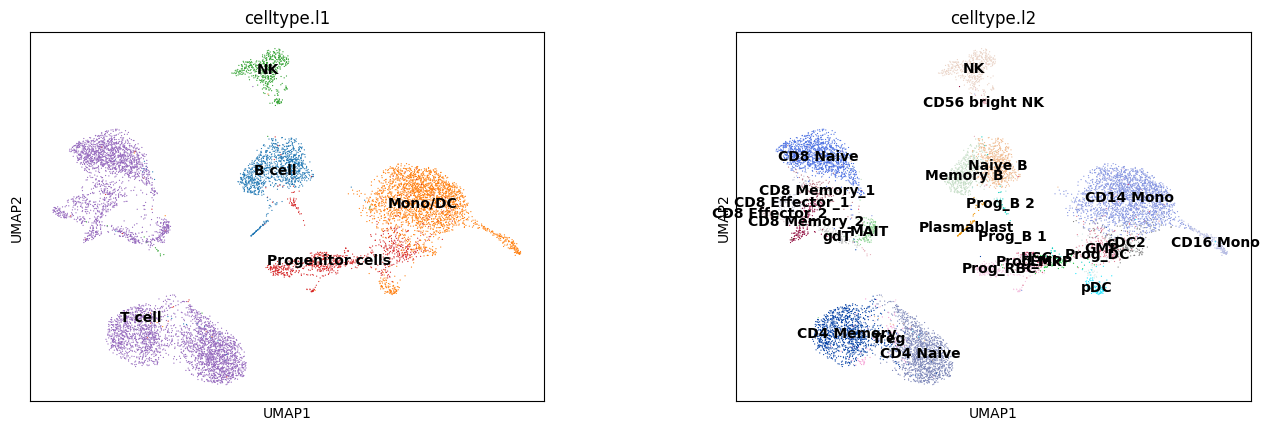

In [10]:
sc.pl.umap(protein_adata, color=['celltype.l1','celltype.l2'], wspace=0.25, show=True, size=3, legend_loc='on data')

In [5]:
mdata = MuData({"rna": adata_rna_sampled, "adt": adata_adt_sampled})
mdata

MuData object with n_obs × n_vars = 10000 × 17034
  2 modalities
    rna:	10000 x 17009
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'lane', 'donor', 'celltype.l1', 'celltype.l2', 'RNA.weight'
      var:	'gene_symbols'
      layers:	'counts'
    adt:	10000 x 25
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'lane', 'donor', 'celltype.l1', 'celltype.l2', 'RNA.weight'
      layers:	'counts'

## Perform single-cell multi-omics integration using Garfield

In [6]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/2_GSE128639'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=5., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=1.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=42,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/2_GSE128639


In [7]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 19 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Init_matching done!
Finding initial pivots costs 185.11 seconds.
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
7000/10000 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
6000/6000 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [8]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Number of training nodes: 9000
Number of validation nodes: 1000
Number of training edges: 65518
Number of validation edges: 7279
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.9293; val_auprc_score: 0.9128; val_best_acc_score: 0.8625; val_best_f1_score: 0.8722; train_kl_reg_loss: 76.3395; train_edge_recon_loss: 5410.8076; train_gene_expr_recon_loss: 59964.6863; train_lambda_latent_adj_recon_loss: 1060.7181; train_lambda_latent_contrastive_instanceloss: 7.1038; train_lambda_latent_contrastive_clusterloss: 3.6829; train_global_loss: 66523.3386; train_optim_loss: 66523.3386; val_kl_reg_loss: 75.4647; val_edge_recon_loss: 4435.8820; val_gene_expr_recon_loss: 42257.2539; val_lambda_latent_adj_recon_loss: 1155.1091; val_lambda_latent_contrastive_instanceloss: 6.7304; val_lambda_latent_contrastive_clusterloss: 3.5759; val_global_loss: 47934.0176; val_optim_loss: 47934.0176
Epoch 2/100 

In [9]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [10]:
model.adata

AnnData object with n_obs × n_vars = 10000 × 3025
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ADT', 'rna:nFeature_ADT', 'rna:lane', 'rna:donor', 'rna:celltype.l1', 'rna:celltype.l2', 'rna:RNA.weight', 'rna:n_genes', 'adt:orig.ident', 'adt:nCount_RNA', 'adt:nFeature_RNA', 'adt:nCount_ADT', 'adt:nFeature_ADT', 'adt:lane', 'adt:donor', 'adt:celltype.l1', 'adt:celltype.l2', 'adt:RNA.weight'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'umap'
    obsm: 'feat', 'garfield_latent', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'garfield_latent_distances', 'garfield_latent_connectivities'

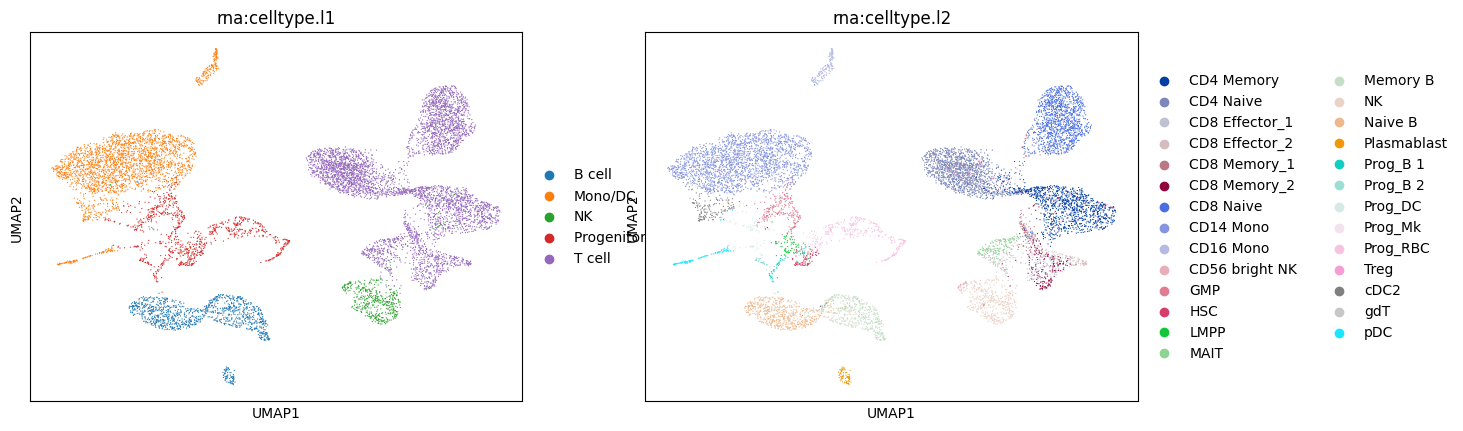

In [11]:
sc.pl.umap(model.adata, color=['rna:celltype.l1', 'rna:celltype.l2'], show=True, size=3) 

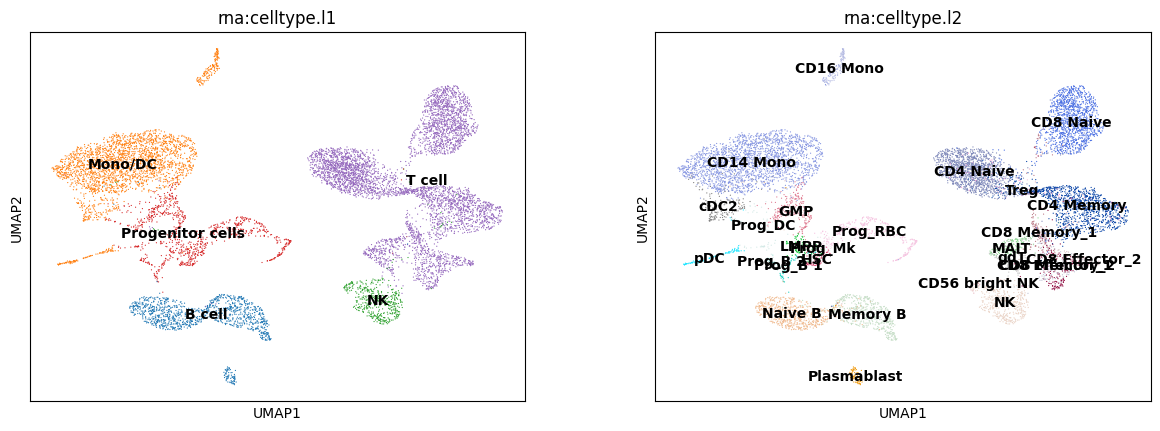

In [13]:
sc.pl.umap(model.adata, color=['rna:celltype.l1', 'rna:celltype.l2'], 
           wspace=0.15, show=True, size=3, legend_loc='on data') 

In [15]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/2_GSE128639/model/attr.pkl


In [25]:
import scanpy as sc

workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/2_GSE128639'
model_folder_path = f"{workdir}/model"

# Load trained 
adata = sc.read_h5ad(f"{model_folder_path}/adata_ref.h5ad")
adata

AnnData object with n_obs × n_vars = 10000 × 3025
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ADT', 'rna:nFeature_ADT', 'rna:lane', 'rna:donor', 'rna:celltype.l1', 'rna:celltype.l2', 'rna:RNA.weight', 'rna:n_genes', 'adt:orig.ident', 'adt:nCount_RNA', 'adt:nFeature_RNA', 'adt:nCount_ADT', 'adt:nFeature_ADT', 'adt:lane', 'adt:donor', 'adt:celltype.l1', 'adt:celltype.l2', 'adt:RNA.weight'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'rna:celltype.l1_colors', 'rna:celltype.l2_colors', 'umap'
    obsm: 'X_umap', 'garfield_latent'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'garfield_latent_connectivities', 'garfield_latent_distances'

## 3_GSE150599 dataset

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.6'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_adt_data(adt_file):
    """Read ADT data from the specified CSV file and return it as an AnnData object."""
    adt_df = pd.read_csv(adt_file, index_col=0)
    adt_df = adt_df.T  # Transpose to match AnnData format
    adt = sc.AnnData(X=adt_df.values)
    adt.var_names = adt_df.columns  # Set feature names
    adt.obs_names = adt_df.index  # Set barcode names
    return adt

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, adt_file, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        adt_file (str): Path to the CSV file containing ADT data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(adt_file)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        adt = read_adt_data(adt_file)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    adt.obs = adt.obs.join(metadata, how="left")

    return {"rna": rna, "adt": adt}

# Example usage with provided file paths
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch1/RNA'
adt_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch1/ADT.csv'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch1/metadata.csv'

# Read the data of Batch1(spleen_lymph_111)
data = read_multiomics_data(rna_dir, adt_file, metadata_file)

# Access RNA and ADT data separately
rna1 = data["rna"]
adt1 = data["adt"]
rna1.layers['counts'] = rna1.X.copy()
adt1.layers['counts'] = adt1.X.copy()

## batch 2 (spleen_lymph_111)
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch2/RNA'
adt_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch2/ADT.csv'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_111/Batch2/metadata.csv'

# Read the data of Batch1
data = read_multiomics_data(rna_dir, adt_file, metadata_file)

# Access RNA and ADT data separately
rna2 = data["rna"]
adt2 = data["adt"]
rna2.layers['counts'] = rna2.X.copy()
adt2.layers['counts'] = adt2.X.copy()

## concat rna1 and rna2
rna_spleen_lymph_111 = rna1.concatenate(rna2, batch_key='batch', batch_categories=['Batch1', 'Batch2'])
adt_spleen_lymph_111 = adt1.concatenate(adt2, batch_key='batch', batch_categories=['Batch1', 'Batch2'])

## spleen_lymph_206
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch1/RNA'
adt_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch1/ADT.csv'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch1/metadata.csv'

# Read the data of Batch1(spleen_lymph_111)
data = read_multiomics_data(rna_dir, adt_file, metadata_file)

# Access RNA and ADT data separately
rna1 = data["rna"]
adt1 = data["adt"]
rna1.layers['counts'] = rna1.X.copy()
adt1.layers['counts'] = adt1.X.copy()

## batch 2 (spleen_lymph_206)
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch2/RNA'
adt_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch2/ADT.csv'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/3_GSE150599/spleen_lymph_206/Batch2/metadata.csv'

# Read the data of Batch1
data = read_multiomics_data(rna_dir, adt_file, metadata_file)

# Access RNA and ADT data separately
rna2 = data["rna"]
adt2 = data["adt"]
rna2.layers['counts'] = rna2.X.copy()
adt2.layers['counts'] = adt2.X.copy()

## concat rna1 and rna2
rna_spleen_lymph_206 = rna1.concatenate(rna2, batch_key='batch', batch_categories=['Batch1', 'Batch2'])
adt_spleen_lymph_206 = adt1.concatenate(adt2, batch_key='batch', batch_categories=['Batch1', 'Batch2'])

## concat rna_spleen_lymph_111 and rna_spleen_lymph_206
rna = rna_spleen_lymph_111.concatenate(rna_spleen_lymph_206, batch_key='Batch', batch_categories=['spleen_lymph_111', 'spleen_lymph_206'])
adt = adt_spleen_lymph_111.concatenate(adt_spleen_lymph_206, batch_key='Batch', batch_categories=['spleen_lymph_111', 'spleen_lymph_206'])

Reading multiomics data: 100%|██████████| 3/3 [00:09<00:00,  3.24s/it]


## rna_spleen_lymph_111 dataset

In [13]:
list(adt_spleen_lymph_111.var_names)

['ADT_CD102_A0104',
 'ADT_CD103_A0201',
 'ADT_CD106_A0226',
 'ADT_CD115(CSF-1R)_A0105',
 'ADT_CD117(c-Kit)_A0012',
 'ADT_CD11a_A0595',
 'ADT_CD11c_A0106',
 'ADT_CD122(IL-2Rb)_A0227',
 'ADT_CD127(IL-7Ra)_A0198',
 'ADT_CD134(OX-40)_A0195',
 'ADT_CD135_A0098',
 'ADT_CD137_A0194',
 'ADT_CD14_A0424',
 'ADT_CD140a_A0573',
 'ADT_CD15(SSEA-1)_A0076',
 'ADT_CD150(SLAM)_A0203',
 'ADT_CD16-32_A0109',
 'ADT_CD169(Siglec-1)_A0440',
 'ADT_CD172a(SIRPa)_A0422',
 'ADT_CD183(CXCR3)_A0228',
 'ADT_CD184(CXCR4)_A0444',
 'ADT_CD19_A0093',
 'ADT_CD192(CCR2)_A0426',
 'ADT_CD195(CCR5)_A0376',
 'ADT_CD196(CCR6)_A0225',
 'ADT_CD197(CCR7)_A0377',
 'ADT_CD20_A0192',
 'ADT_CD200(OX2)_A0079',
 'ADT_CD201(EPCR)_A0439',
 'ADT_CD204(Msr1)_A0448',
 'ADT_CD206(MMR)_A0173',
 'ADT_CD21-CD35(CR2-CR1)_A0107',
 'ADT_CD223(LAG-3)_A0378',
 'ADT_CD23_A0108',
 'ADT_CD24_A0212',
 'ADT_CD25_A0097',
 'ADT_CD274(B7-H1_PD-L1)_A0190',
 'ADT_CD278(ICOS)_A0171',
 'ADT_CD279(PD-1)_A0004',
 'ADT_CD28_A0204',
 'ADT_CD29_A0570',
 'ADT_CD300

In [14]:
import re

# 假设 adata.var_names 是一个列表或者类似的对象
var_names = list(adt_spleen_lymph_111.var_names)

# 定义一个函数来提取基因名
def extract_gene_name(var_name):
    if var_name.startswith('ADT'):
        # 提取 _ 之间的基因名
        match = re.search(r'ADT_(.*?)[(_]', var_name)
        if match:
            return match.group(1)  # 返回提取的基因名
    return var_name  # 对于HTO或者没有匹配的情况，返回原symbol

# 使用函数对所有的 var_names 进行处理
processed_var_names = [extract_gene_name(var_name) for var_name in var_names]

# 输出处理后的结果
processed_var_names

['CD102',
 'CD103',
 'CD106',
 'CD115',
 'CD117',
 'CD11a',
 'CD11c',
 'CD122',
 'CD127',
 'CD134',
 'CD135',
 'CD137',
 'CD14',
 'CD140a',
 'CD15',
 'CD150',
 'CD16-32',
 'CD169',
 'CD172a',
 'CD183',
 'CD184',
 'CD19',
 'CD192',
 'CD195',
 'CD196',
 'CD197',
 'CD20',
 'CD200',
 'CD201',
 'CD204',
 'CD206',
 'CD21-CD35',
 'CD223',
 'CD23',
 'CD24',
 'CD25',
 'CD274',
 'CD278',
 'CD279',
 'CD28',
 'CD29',
 'CD300LG',
 'CD301a',
 'CD301b',
 'CD304',
 'CD326',
 'CD335',
 'CD357',
 'CD36',
 'CD366',
 'CD370',
 'CD38',
 'CD4',
 'CD41',
 'CD43',
 'CD45',
 'CD45.1',
 'CD45.2',
 'CD45R-B220',
 'CD48',
 'CD49d',
 'CD5',
 'CD54',
 'CD55',
 'CD62L',
 'CD62P',
 'CD63',
 'CD64',
 'CD68',
 'CD69',
 'CD71',
 'CD73',
 'CD79b',
 'CD83',
 'CD86',
 'CD8a',
 'CD8b',
 'CD90.1',
 'CD90.2',
 'CD93',
 'CX3CR1',
 'ESAM',
 'F4-80',
 'FceRIa',
 'FolateReceptorb',
 'H-2KbboundtoSIINFEKL',
 'I-A-I-E',
 'IRF4',
 'IgD',
 'IgM',
 'Ly-6A-E',
 'Ly-6C',
 'MAdCAM-1',
 'MERTK',
 'NK-1.1',
 'Notch1',
 'PanendothelialCellA

In [15]:
adt_spleen_lymph_111.var['original_gene_symbols'] = adt_spleen_lymph_111.var_names
adt_spleen_lymph_111.var['gene_symbols'] = processed_var_names
adt_spleen_lymph_111.var_names = adt_spleen_lymph_111.var['gene_symbols']

In [22]:
import pkgutil
import pandas as pd
import numpy as np
import io

correspondence = pkgutil.get_data('Garfield', 'data/gene_anno/protein_gene_conversion.csv')
correspondence = pd.read_csv(io.BytesIO(correspondence), encoding='utf8')

rna_protein_correspondence = []
for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in adt_spleen_lymph_111.var_names:
        continue
    if curr_rna_names.find(
            'Ignore') != -1:  # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/')  # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in rna_spleen_lymph_111.var_names:
            rna_protein_correspondence.append([r, curr_protein_name])
rna_protein_correspondence = np.array(rna_protein_correspondence)

In [24]:
adt_spleen_lymph_111.var_names

Index(['CD102', 'CD103', 'CD106', 'CD115', 'CD117', 'CD11a', 'CD11c', 'CD122',
       'CD127', 'CD134',
       ...
       'TCRVr3', 'TCRbchain', 'TCRr-d', 'TER-119-ErythroidCells', 'Tim-4',
       'XCR1', 'anti-P2RY12', 'integrinb7', 'HTO_B6_spl_r4_206_A0301',
       'HTO_B6_LN_r4_206_A0302'],
      dtype='object', name='gene_symbols', length=112)

In [23]:
rna_protein_correspondence

array([], dtype=float64)

In [19]:
## var_names 交集
rna_spleen_lymph_111.var_names.intersection(adt_spleen_lymph_111.var_names)

Index(['Notch1'], dtype='object', name='gene_symbols')

In [3]:
adata = sc.read_h5ad('/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_Protein/4_GSE194122/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad')
adata

AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [4]:
adata.var['feature_types'].value_counts()

feature_types
GEX    13953
ADT      134
Name: count, dtype: int64

In [5]:
## 提取 RNA 和 ADT 数据
rna = adata[:, adata.var['feature_types'] == 'GEX'].copy()
adt = adata[:, adata.var['feature_types'] == 'ADT'].copy()

## downsample 
import numpy as np

# 设定下采样的细胞数量
n_cells = 10000
# 设置随机种子以确保重复性
random_seed = 42
np.random.seed(random_seed)
# 随机选择 1 万个细胞的索引
random_indices = np.random.choice(rna.shape[0], n_cells, replace=False)
# 根据随机索引选择细胞
adata_rna_sampled = rna[random_indices].copy()
adata_adt_sampled = adt[random_indices].copy()

adata_rna_sampled.X = adata_rna_sampled.layers['counts']
adata_adt_sampled.X = adata_adt_sampled.layers['counts']

In [13]:
mdata = MuData({"rna": adata_rna_sampled, "adt": adata_adt_sampled})
mdata

MuData object with n_obs × n_vars = 10000 × 14087
  2 modalities
    rna:	10000 x 13953
      obs:	'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
      var:	'feature_types', 'gene_id'
      uns:	'dataset_id', 'genome', 'organism'
      obsm:	'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
      layers:	'counts'
    adt:	10000 x 134
      obs:	'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
      var:	'feature_types', 'gene_id'
      uns:	'dataset_id', 'genome', 'organism'
      obsm:	'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
      layers:	'counts'

## Perform single-cell multi-omics integration using Garfield

In [14]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/4_GSE194122/'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'adt'],
    sample_col='batch',  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=True,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=5., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=1.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=42,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/4_GSE194122/


In [15]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
There are 80 common genes in RNA and ADT datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Init_matching done!
Finding initial pivots costs 161.45 seconds.
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
7000/10000 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
6000/6000 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [16]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Number of training nodes: 9000
Number of validation nodes: 1000
Number of training edges: 62649
Number of validation edges: 6961
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.9175; val_auprc_score: 0.9110; val_best_acc_score: 0.8395; val_best_f1_score: 0.8432; train_kl_reg_loss: 67.6715; train_edge_recon_loss: 5472.0526; train_gene_expr_recon_loss: 122576.9604; train_lambda_latent_adj_recon_loss: 997.4691; train_lambda_latent_contrastive_instanceloss: 7.2215; train_lambda_latent_contrastive_clusterloss: 3.6969; train_gene_expr_mmd_loss: 72076.7668; train_global_loss: 201201.8379; train_optim_loss: 201201.8379; val_kl_reg_loss: 30.6761; val_edge_recon_loss: 5258.0476; val_gene_expr_recon_loss: 110094.3125; val_lambda_latent_adj_recon_loss: 1057.9536; val_lambda_latent_contrastive_instanceloss: 7.1038; val_lambda_latent_contrastive_clusterloss: 3.6810; val_gene_expr_mmd_loss: 692

In [17]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [18]:
model.adata

AnnData object with n_obs × n_vars = 10000 × 3134
    obs: 'rna:GEX_n_genes_by_counts', 'rna:GEX_pct_counts_mt', 'rna:GEX_size_factors', 'rna:GEX_phase', 'rna:ADT_n_antibodies_by_counts', 'rna:ADT_total_counts', 'rna:ADT_iso_count', 'rna:cell_type', 'rna:batch', 'rna:ADT_pseudotime_order', 'rna:GEX_pseudotime_order', 'rna:Samplename', 'rna:Site', 'rna:DonorNumber', 'rna:Modality', 'rna:VendorLot', 'rna:DonorID', 'rna:DonorAge', 'rna:DonorBMI', 'rna:DonorBloodType', 'rna:DonorRace', 'rna:Ethnicity', 'rna:DonorGender', 'rna:QCMeds', 'rna:DonorSmoker', 'rna:is_train', 'rna:n_genes', 'adt:GEX_n_genes_by_counts', 'adt:GEX_pct_counts_mt', 'adt:GEX_size_factors', 'adt:GEX_phase', 'adt:ADT_n_antibodies_by_counts', 'adt:ADT_total_counts', 'adt:ADT_iso_count', 'adt:cell_type', 'adt:batch', 'adt:ADT_pseudotime_order', 'adt:GEX_pseudotime_order', 'adt:Samplename', 'adt:Site', 'adt:DonorNumber', 'adt:Modality', 'adt:VendorLot', 'adt:DonorID', 'adt:DonorAge', 'adt:DonorBMI', 'adt:DonorBloodType', 'a

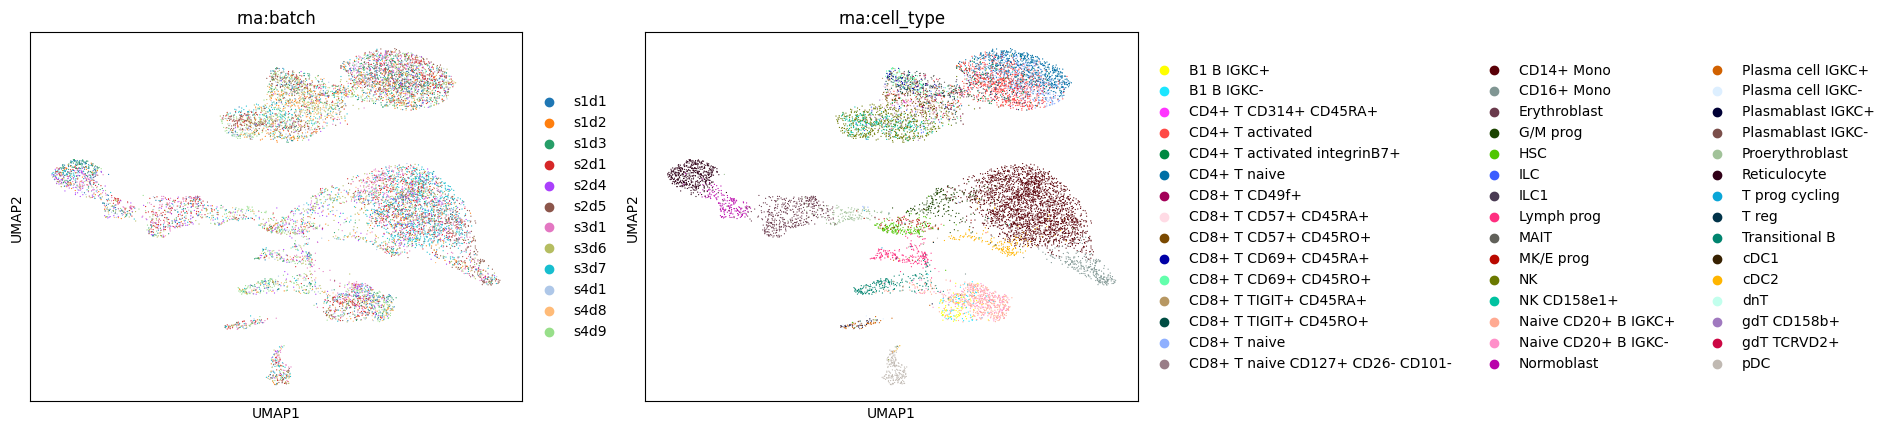

In [19]:
sc.pl.umap(model.adata, color=['rna:batch', 'rna:cell_type'], show=True, size=3) 

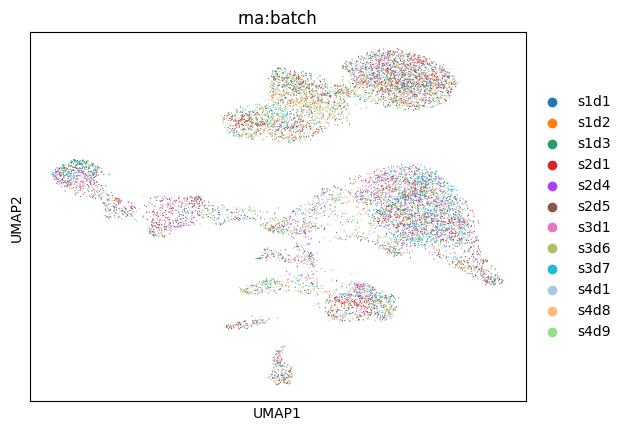

In [22]:
sc.pl.umap(model.adata, color=['rna:batch'], 
           wspace=0.15, show=True, size=3)

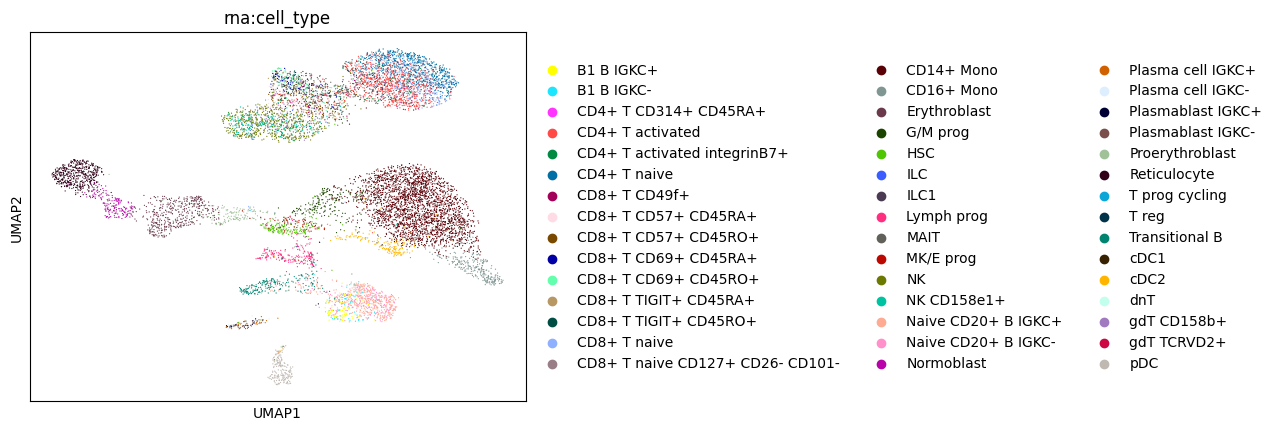

In [21]:
sc.pl.umap(model.adata, color=['rna:cell_type'], 
           wspace=0.15, show=True, size=3) 

In [24]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_Protein/4_GSE194122//model/attr.pkl
